# FCFS Simulation Results From the Note-Aligned Model

This notebook runs the first FCFS simulation described in the note.
It keeps the policy simple on purpose: the goal is to understand the delay feedback loop before comparing richer allocation rules.

## Sections
- 1. Scenario inputs
- 2. One FCFS baseline run
- 3. Baseline plots
- 4. Backlog dynamics
- 5. Showcase scenario: where the behavior functions matter
- 6. Sensitivity to total arrival rate $\lambda$


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "appointment_simulation").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

for module_name in list(sys.modules):
    if module_name == "appointment_simulation" or module_name.startswith("appointment_simulation."):
        del sys.modules[module_name]

from IPython.display import display

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from appointment_simulation import (
    FCFSPolicy,
    make_note_config,
    make_two_class_classes,
    model_setup_frame,
    replication_summary_frame,
    simulate,
    simulate_replications,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)


## 1. Scenario Inputs

The baseline inputs below mirror the note: one total arrival rate $\lambda$, one class share $p$, one FCFS policy, and one choice for each behavior family.
Increase `measure_days` or the number of replications later if you want smoother empirical summaries.
The extra backlog-view inputs are only for visualization: they let you inspect how the calendar fills under a slightly heavier FCFS load without changing the main baseline scenario.


In [2]:
TOTAL_LAMBDA = 1.1
CLASS_1_SHARE = 7 / 12

BALKING_OPTION = "step_access"
CANCELLATION_OPTION = "moderate"
NO_SHOW_OPTION = "source_aligned"

BACKLOG_VIEW_LAMBDA = 1.0
BACKLOG_PLOT_DAYS = 90
BACKLOG_HEATMAP_DAYS = 60
SHOWCASE_LAMBDA = 1.05

SIM_CONFIG = make_note_config(
    horizon_days=15,
    slots_per_day=25,
    burn_in_days=250,
    measure_days=365,
    access_target_days=30,
    rng_seed=7,
)
POLICY = FCFSPolicy()

CLASS_CONFIGS = make_two_class_classes(
    total_lambda=TOTAL_LAMBDA,
    class_1_share=CLASS_1_SHARE,
    balking_option=BALKING_OPTION,
    cancellation_option=CANCELLATION_OPTION,
    no_show_option=NO_SHOW_OPTION,
)

scenario_frame = model_setup_frame(
    total_lambda=TOTAL_LAMBDA,
    class_1_share=CLASS_1_SHARE,
    class_configs=CLASS_CONFIGS,
    balking_option=BALKING_OPTION,
    cancellation_option=CANCELLATION_OPTION,
    no_show_option=NO_SHOW_OPTION,
)
config_frame = pd.DataFrame(
    [
        {
            "horizon_days": SIM_CONFIG.horizon_days,
            "slots_per_day": SIM_CONFIG.slots_per_day,
            "burn_in_days": SIM_CONFIG.burn_in_days,
            "measure_days": SIM_CONFIG.measure_days,
            "access_target_days": SIM_CONFIG.access_target_days,
            "policy": type(POLICY).__name__,
        }
    ]
)

display(scenario_frame)
display(config_frame)


,class_id,label,lambda_total,p,lambda_i,b_i option,phi_i option,xi_i option,phi_base_i,phi_slope_i,phi_cap_i
0,1,MRI-like diagnostic,1.1,0.583333,0.641667,step_access,moderate,source_aligned,0.01,0.008,0.12
1,2,Behavioral-health follow-up,1.1,0.583333,0.458333,step_access,moderate,source_aligned,0.02,0.012,0.18


,horizon_days,slots_per_day,burn_in_days,measure_days,access_target_days,policy
0,15,25,250,365,30,FCFSPolicy


## 2. One FCFS Baseline Run

The first block runs one full simulation and pulls out the two objects emphasized in the note:

- the aggregate KPIs that summarize access, service, and utilization
- the derived state table $X_{i,r}^D$ for a measured day


In [3]:
def collect_baseline_kpis(result) -> pd.Series:
    """Return the aggregate KPIs used throughout the notebook."""
    aggregate = result.summary_aggregate
    slot_aggregate = result.slot_summary_aggregate
    return pd.Series(
        {
            "mean_delay_booked": aggregate["mean_delay_booked"],
            "mean_delay_served": aggregate["mean_delay_served"],
            "booked_within_access_target_per_arrival": aggregate["booked_within_access_target_per_arrival"],
            "served_per_booked": aggregate["served_per_booked"],
            "booked_slot_utilization": slot_aggregate["booked_slot_utilization"],
            "attended_slot_utilization": slot_aggregate["attended_slot_utilization"],
            "empty_slots": slot_aggregate["empty_slots"],
        },
        name="value",
    )


def state_snapshot(result, measured_day: int = 0) -> pd.DataFrame:
    """Turn the recorded state log into the day-start table X_{i,r}^D."""
    frame = (
        result.state_log.query("measured_day == @measured_day")
        .pivot(index="class_id", columns="residual_delay", values="count")
        .fillna(0)
        .astype(int)
    )
    frame.columns = [f"r={column}" for column in frame.columns]
    return frame


def delay_distribution_frame(result) -> pd.DataFrame:
    """Collect booked-delay counts in a tidy frame for plotting."""
    frames = []
    for class_id, series in result.delay_distribution_by_class.items():
        label = result.summary_by_class.set_index("class_id").loc[class_id, "label"]
        class_frame = series.rename_axis("tau").reset_index(name="count")
        class_frame["label"] = label
        frames.append(class_frame)
    if not frames:
        return pd.DataFrame(columns=["tau", "count", "label"])
    return pd.concat(frames, ignore_index=True)


def run_fcfs_lambda_sweep(total_lambdas, replications: int = 6, base_seed: int = 100):
    """Run repeated FCFS scenarios over a range of total arrival rates."""
    aggregate_frames = []
    class_frames = []
    for scenario_index, total_lambda in enumerate(total_lambdas):
        classes = make_two_class_classes(
            total_lambda=total_lambda,
            class_1_share=CLASS_1_SHARE,
            balking_option=BALKING_OPTION,
            cancellation_option=CANCELLATION_OPTION,
            no_show_option=NO_SHOW_OPTION,
        )
        results = simulate_replications(
            classes,
            config=SIM_CONFIG,
            policy=POLICY,
            replications=replications,
            base_seed=base_seed + scenario_index * replications,
        )
        aggregate_frame = replication_summary_frame(results)
        aggregate_frame["lambda_total"] = total_lambda
        aggregate_frames.append(aggregate_frame)

        for replication, result in enumerate(results):
            class_frame = result.summary_by_class[
                [
                    "class_id",
                    "label",
                    "mean_delay_booked",
                    "booked_within_access_target_per_arrival",
                    "served_per_booked",
                ]
            ].copy()
            class_frame["lambda_total"] = total_lambda
            class_frame["replication"] = replication
            class_frames.append(class_frame)

    return pd.concat(aggregate_frames, ignore_index=True), pd.concat(class_frames, ignore_index=True)


def backlog_heatmap_frame(result, class_id: int | None = None, max_days: int = 60) -> pd.DataFrame:
    """Pivot the state log into a measured-day by residual-delay heatmap table."""
    frame = result.state_log.copy()
    if class_id is not None:
        frame = frame[frame["class_id"] == class_id]
    frame = frame.groupby(["measured_day", "residual_delay"], as_index=False)["count"].sum()
    frame = frame[frame["measured_day"] < max_days]
    heatmap = frame.pivot(index="measured_day", columns="residual_delay", values="count").fillna(0)
    heatmap = heatmap.reindex(columns=range(result.config.horizon_days), fill_value=0)
    return heatmap


def average_backlog_profile_frame(result) -> pd.DataFrame:
    """Average the day-start state over measured days to show where the queue sits."""
    by_class = (
        result.state_log.groupby(["class_id", "residual_delay"], as_index=False)["count"].mean()
        .merge(result.summary_by_class[["class_id", "label"]], on="class_id", how="left")
        .rename(columns={"count": "mean_count"})
    )
    aggregate = (
        result.state_log.groupby(["measured_day", "residual_delay"], as_index=False)["count"].sum()
        .groupby("residual_delay", as_index=False)["count"].mean()
        .assign(label="all classes")
        .rename(columns={"count": "mean_count"})
    )
    return by_class, aggregate


def backlog_daily_frames(result, max_days: int = 90) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Return aggregate and class-specific day-start backlog frames for plotting."""
    aggregate = result.daily_journal_aggregate.query("measured_day < @max_days").copy()
    aggregate["future_backlog"] = (
        aggregate["scheduled_start_of_day"] - aggregate["scheduled_for_today_start"]
    )
    by_class = result.daily_journal_by_class.query("measured_day < @max_days").copy()
    by_class["future_backlog"] = by_class["scheduled_start_of_day"] - by_class["scheduled_for_today_start"]
    return aggregate, by_class


def run_showcase_scenarios(total_lambda: float = 1.05):
    """Run a small set of FCFS scenarios that isolate where the behavior matters."""
    scenario_specs = [
        {
            "scenario": "Reference realistic",
            "balking_option": "step_access",
            "cancellation_option": "moderate",
            "no_show_option": "source_aligned",
        },
        {
            "scenario": "More delay-sensitive no-show",
            "balking_option": "step_access",
            "cancellation_option": "moderate",
            "no_show_option": "more_delay_sensitive",
        },
        {
            "scenario": "Heavier cancellation",
            "balking_option": "step_access",
            "cancellation_option": "reschedule_heavy",
            "no_show_option": "source_aligned",
        },
    ]

    aggregate_records = []
    class_records = []
    results = {}

    for spec in scenario_specs:
        classes = make_two_class_classes(
            total_lambda=total_lambda,
            class_1_share=CLASS_1_SHARE,
            balking_option=spec["balking_option"],
            cancellation_option=spec["cancellation_option"],
            no_show_option=spec["no_show_option"],
        )
        result = simulate(classes, config=SIM_CONFIG, policy=POLICY)
        results[spec["scenario"]] = result

        aggregate = result.summary_aggregate
        slot = result.slot_summary_aggregate
        daily = result.daily_journal_aggregate
        aggregate_records.append(
            {
                "scenario": spec["scenario"],
                "lambda_total": total_lambda,
                "mean_delay_booked": aggregate["mean_delay_booked"],
                "served_per_booked": aggregate["served_per_booked"],
                "booked_within_access_target_per_arrival": aggregate["booked_within_access_target_per_arrival"],
                "booked_slot_utilization": slot["booked_slot_utilization"],
                "attended_slot_utilization": slot["attended_slot_utilization"],
                "mean_scheduled_start_of_day": daily["scheduled_start_of_day"].mean(),
                "mean_future_backlog": (daily["scheduled_start_of_day"] - daily["scheduled_for_today_start"]).mean(),
                "canceled_total": aggregate["canceled"],
                "no_shows_total": aggregate["no_shows"],
            }
        )

        class_frame = result.summary_by_class[[
            "class_id",
            "label",
            "mean_delay_booked",
            "served_per_booked",
            "booked_per_arrival",
            "canceled",
            "no_shows",
            "booked",
        ]].copy()
        class_frame["scenario"] = spec["scenario"]
        class_frame["canceled_per_booked"] = class_frame["canceled"] / class_frame["booked"]
        class_frame["no_shows_per_booked"] = class_frame["no_shows"] / class_frame["booked"]
        class_records.append(class_frame)

    return pd.DataFrame(aggregate_records), pd.concat(class_records, ignore_index=True), results


In [4]:
baseline_result = simulate(CLASS_CONFIGS, config=SIM_CONFIG, policy=POLICY)

display(collect_baseline_kpis(baseline_result).to_frame())
display(baseline_result.summary_by_class)
display(state_snapshot(baseline_result, measured_day=0))
display(
    baseline_result.daily_journal_aggregate.head(10)[
        [
            "measured_day",
            "scheduled_start_of_day",
            "arrivals",
            "booked",
            "served",
            "empty_slots",
            "mean_tau_booked_new_bookings",
        ]
    ]
)


,value
mean_delay_booked,2.871787
mean_delay_served,2.833622
booked_within_access_target_per_arrival,0.972734
served_per_booked,0.816839
booked_slot_utilization,0.999452
attended_slot_utilization,0.883726
empty_slots,5.000000


,class_id,label,arrivals,booked,balked,no_offer,not_booked,booked_within_access_target,canceled,no_shows,served,still_scheduled_end,mean_delay_booked,mean_delay_served,served_per_booked,booked_per_arrival,booked_within_access_target_per_arrival,booked_within_access_target_per_booked
0,1,MRI-like diagnostic,5985,5862,123,0,123,5862,346,158,5358,0,2.874957,2.846398,0.914023,0.979449,0.979449,1.0
1,2,Behavioral-health follow-up,4174,4020,154,0,154,4020,411,895,2714,0,2.867164,2.808401,0.675124,0.963105,0.963105,1.0


,r=0,r=1,r=2,r=3,r=4,r=5,r=6,r=7,r=8,r=9,r=10,r=11,r=12,r=13,r=14
class_id,,,,,,,,,,,,,,,
1,15,15,6,0,0,0,0,0,0,0,0,0,0,0,0
2,10,10,1,0,0,0,0,0,0,0,0,0,0,0,0


,measured_day,scheduled_start_of_day,arrivals,booked,served,empty_slots,mean_tau_booked_new_bookings
0,0,57,38,38,18,0,2.526316
1,1,69,31,29,22,0,2.724138
2,2,73,23,22,23,0,2.909091
3,3,69,25,25,21,0,2.760000
4,4,67,28,27,23,0,2.703704
5,5,67,29,29,21,0,2.724138
6,6,71,25,25,23,0,2.840000
7,7,70,30,30,21,1,2.900000
8,8,74,30,28,23,0,2.964286
9,9,76,21,19,23,0,2.947368


## 3. Baseline Plots

These plots correspond to the main outputs of the first FCFS model: delay, access, service, and slot utilization.
A separate section just below focuses specifically on backlog build-up and calendar structure.


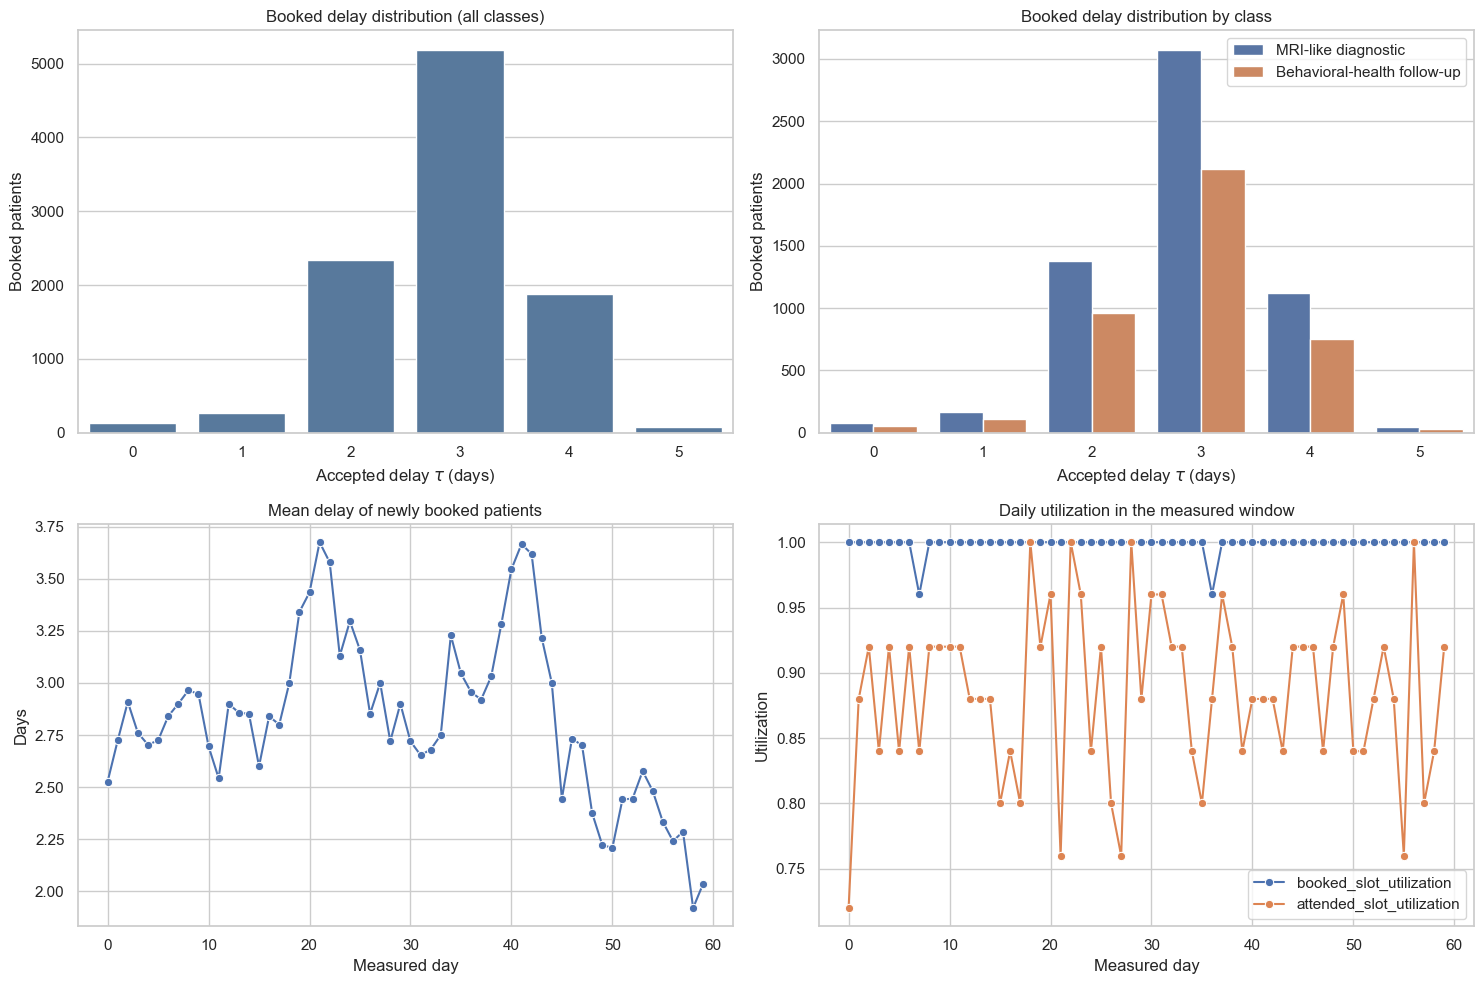

In [5]:
baseline_daily = baseline_result.daily_journal_aggregate.head(60).copy()
baseline_delays = delay_distribution_frame(baseline_result)
aggregate_delay_distribution = baseline_result.delay_distribution_aggregate.rename_axis("tau").reset_index(name="count")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.barplot(data=aggregate_delay_distribution, x="tau", y="count", color="#4C78A8", ax=axes[0, 0])
axes[0, 0].set_title("Booked delay distribution (all classes)")
axes[0, 0].set_xlabel(r"Accepted delay $\tau$ (days)")
axes[0, 0].set_ylabel("Booked patients")

sns.barplot(data=baseline_delays, x="tau", y="count", hue="label", ax=axes[0, 1])
axes[0, 1].set_title("Booked delay distribution by class")
axes[0, 1].set_xlabel(r"Accepted delay $\tau$ (days)")
axes[0, 1].set_ylabel("Booked patients")
axes[0, 1].legend(title="")

sns.lineplot(
    data=baseline_daily,
    x="measured_day",
    y="mean_tau_booked_new_bookings",
    marker="o",
    ax=axes[1, 0],
)
axes[1, 0].set_title("Mean delay of newly booked patients")
axes[1, 0].set_xlabel("Measured day")
axes[1, 0].set_ylabel("Days")

journal_utilization = baseline_daily[
    ["measured_day", "booked_slot_utilization", "attended_slot_utilization"]
].melt(id_vars="measured_day", var_name="metric", value_name="value")
sns.lineplot(
    data=journal_utilization,
    x="measured_day",
    y="value",
    hue="metric",
    marker="o",
    ax=axes[1, 1],
)
axes[1, 1].set_title("Daily utilization in the measured window")
axes[1, 1].set_xlabel("Measured day")
axes[1, 1].set_ylabel("Utilization")
axes[1, 1].legend(title="")

plt.tight_layout()


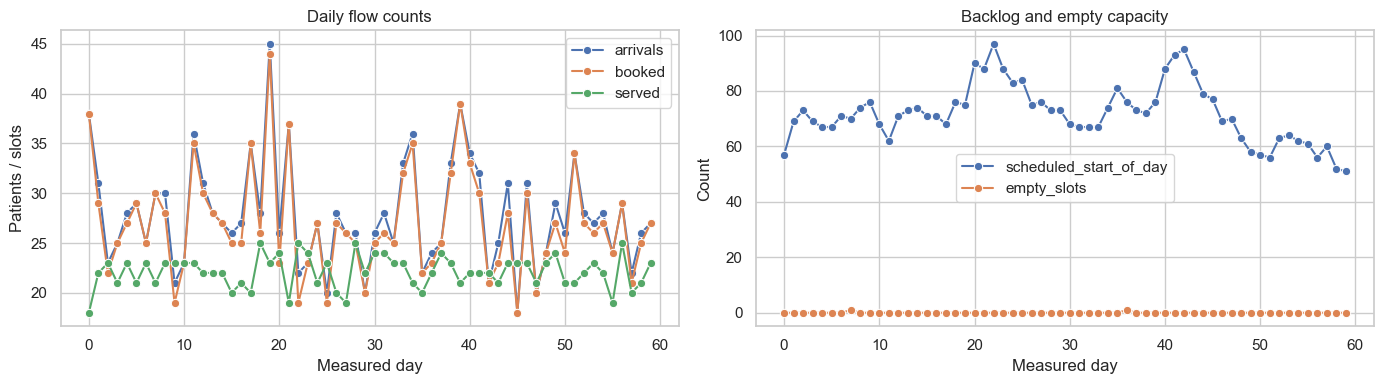

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

flow_df = baseline_daily[["measured_day", "arrivals", "booked", "served"]].melt(
    id_vars="measured_day",
    var_name="metric",
    value_name="count",
)
sns.lineplot(data=flow_df, x="measured_day", y="count", hue="metric", marker="o", ax=axes[0])
axes[0].set_title("Daily flow counts")
axes[0].set_xlabel("Measured day")
axes[0].set_ylabel("Patients / slots")
axes[0].legend(title="")

backlog_df = baseline_daily[["measured_day", "scheduled_start_of_day", "empty_slots"]].melt(
    id_vars="measured_day",
    var_name="metric",
    value_name="value",
)
sns.lineplot(data=backlog_df, x="measured_day", y="value", hue="metric", marker="o", ax=axes[1])
axes[1].set_title("Backlog and empty capacity")
axes[1].set_xlabel("Measured day")
axes[1].set_ylabel("Count")
axes[1].legend(title="")

plt.tight_layout()


## 4. Backlog Dynamics

The baseline scenario is lightly loaded, so the queue stays short. To make the backlog mechanism visible, the next cells run one slightly heavier FCFS scenario with the same behavior functions and class mix, but a larger total arrival rate.

The key objects are:

- `scheduled_start_of_day`: all patients already sitting on the calendar when the day begins
- `scheduled_for_today_start`: the part of the backlog due today
- `future_backlog`: the portion pushed into later days
- the heatmaps of $X_{i,r}^D$: how many class-$i$ patients are scheduled $r$ days ahead on measured day $D$


In [7]:
BACKLOG_CLASSES = make_two_class_classes(
    total_lambda=BACKLOG_VIEW_LAMBDA,
    class_1_share=CLASS_1_SHARE,
    balking_option=BALKING_OPTION,
    cancellation_option=CANCELLATION_OPTION,
    no_show_option=NO_SHOW_OPTION,
)
BACKLOG_RESULT = simulate(BACKLOG_CLASSES, config=SIM_CONFIG, policy=POLICY)
BACKLOG_DAILY, BACKLOG_DAILY_BY_CLASS = backlog_daily_frames(
    BACKLOG_RESULT,
    max_days=BACKLOG_PLOT_DAYS,
)
BACKLOG_PROFILE_BY_CLASS, BACKLOG_PROFILE_AGGREGATE = average_backlog_profile_frame(BACKLOG_RESULT)

display(
    pd.Series(
        {
            'lambda_total': BACKLOG_VIEW_LAMBDA,
            'mean_delay_booked': BACKLOG_RESULT.summary_aggregate['mean_delay_booked'],
            'mean_scheduled_start_of_day': BACKLOG_DAILY['scheduled_start_of_day'].mean(),
            'max_scheduled_start_of_day': BACKLOG_DAILY['scheduled_start_of_day'].max(),
        },
        name='backlog_view',
    ).to_frame()
)


,backlog_view
lambda_total,1.000000
mean_delay_booked,0.416629
mean_scheduled_start_of_day,9.233333
max_scheduled_start_of_day,27.000000


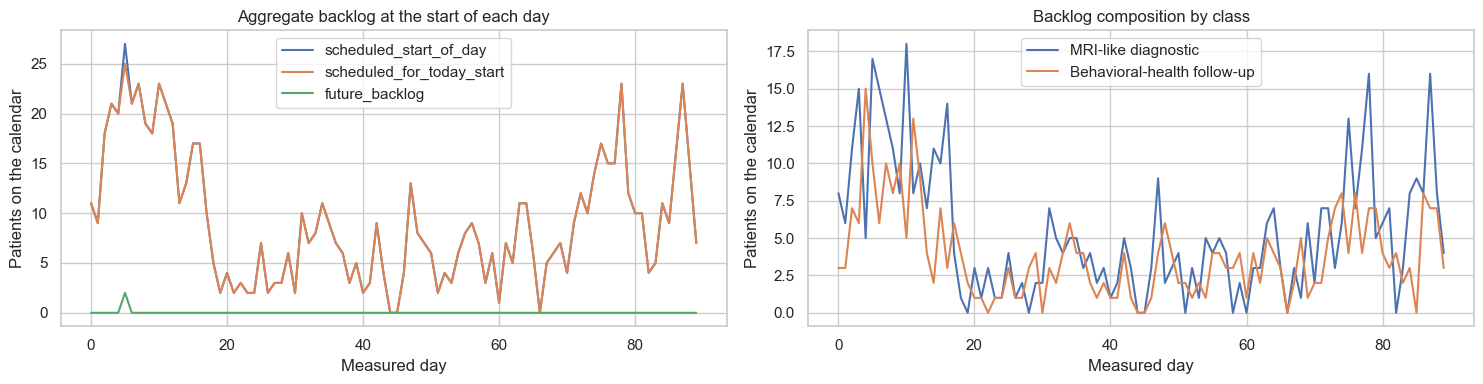

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4), sharex=True)

aggregate_backlog_lines = BACKLOG_DAILY[[
    'measured_day',
    'scheduled_start_of_day',
    'scheduled_for_today_start',
    'future_backlog',
]].melt(id_vars='measured_day', var_name='metric', value_name='count')
sns.lineplot(
    data=aggregate_backlog_lines,
    x='measured_day',
    y='count',
    hue='metric',
    ax=axes[0],
)
axes[0].set_title('Aggregate backlog at the start of each day')
axes[0].set_xlabel('Measured day')
axes[0].set_ylabel('Patients on the calendar')
axes[0].legend(title='')

sns.lineplot(
    data=BACKLOG_DAILY_BY_CLASS,
    x='measured_day',
    y='scheduled_start_of_day',
    hue='label',
    ax=axes[1],
)
axes[1].set_title('Backlog composition by class')
axes[1].set_xlabel('Measured day')
axes[1].set_ylabel('Patients on the calendar')
axes[1].legend(title='')

plt.tight_layout()


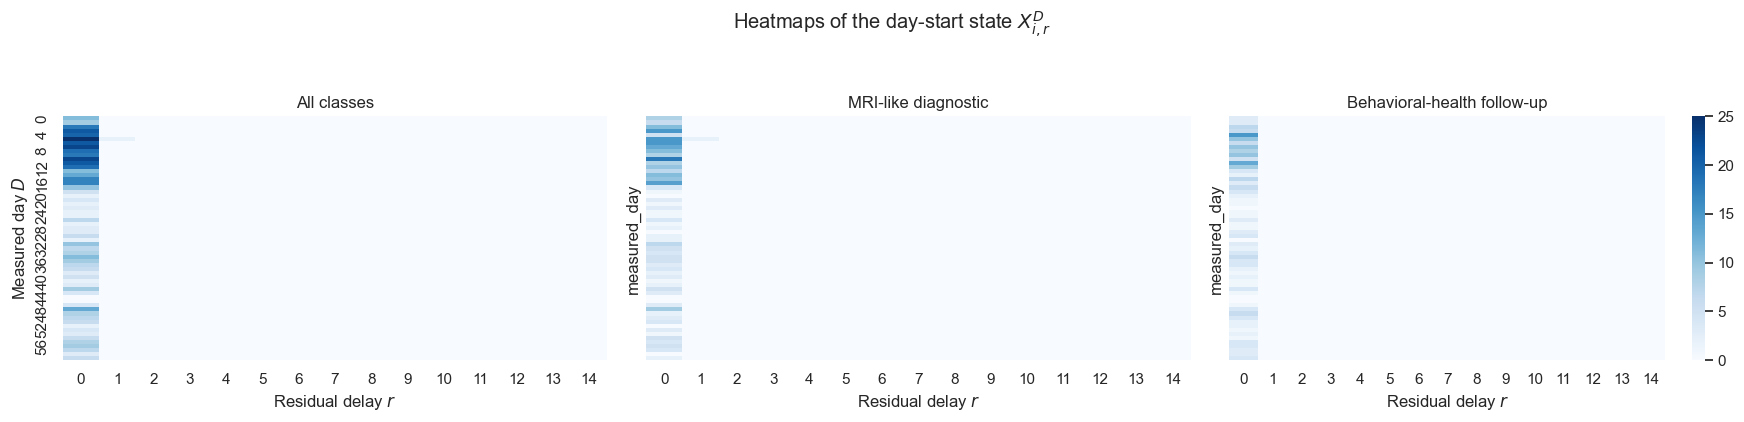

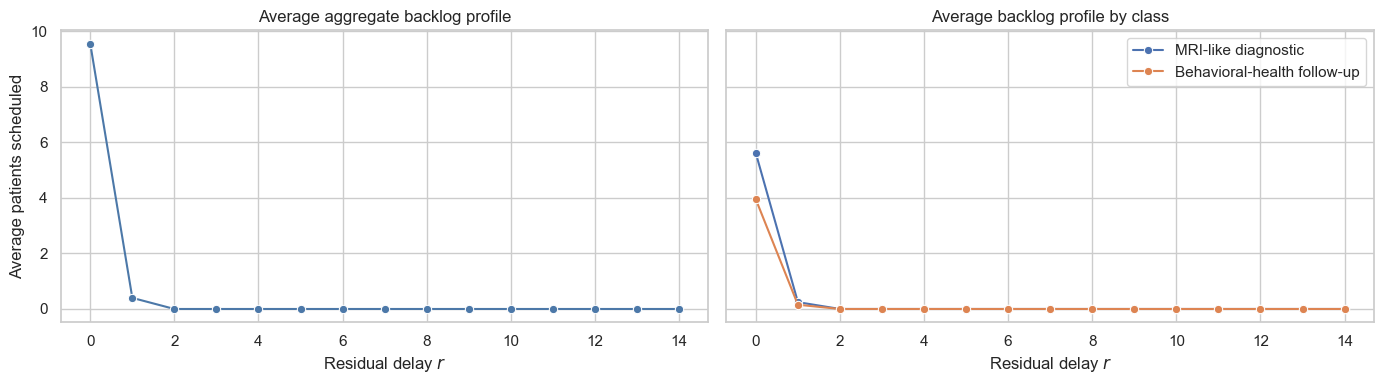

In [9]:
aggregate_heatmap = backlog_heatmap_frame(BACKLOG_RESULT, max_days=BACKLOG_HEATMAP_DAYS)
class_1_heatmap = backlog_heatmap_frame(BACKLOG_RESULT, class_id=1, max_days=BACKLOG_HEATMAP_DAYS)
class_2_heatmap = backlog_heatmap_frame(BACKLOG_RESULT, class_id=2, max_days=BACKLOG_HEATMAP_DAYS)
heatmap_max = max(aggregate_heatmap.to_numpy().max(), class_1_heatmap.to_numpy().max(), class_2_heatmap.to_numpy().max())

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
for axis, heatmap, title in [
    (axes[0], aggregate_heatmap, 'All classes'),
    (axes[1], class_1_heatmap, 'MRI-like diagnostic'),
    (axes[2], class_2_heatmap, 'Behavioral-health follow-up'),
]:
    sns.heatmap(heatmap, cmap='Blues', vmin=0, vmax=heatmap_max, ax=axis, cbar=axis is axes[2])
    axis.set_title(title)
    axis.set_xlabel(r'Residual delay $r$')
axes[0].set_ylabel(r'Measured day $D$')
fig.suptitle(r'Heatmaps of the day-start state $X_{i,r}^D$', y=1.05)
plt.tight_layout()

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
sns.lineplot(
    data=BACKLOG_PROFILE_AGGREGATE,
    x='residual_delay',
    y='mean_count',
    marker='o',
    color='#4C78A8',
    ax=axes[0],
)
axes[0].set_title('Average aggregate backlog profile')
axes[0].set_xlabel(r'Residual delay $r$')
axes[0].set_ylabel('Average patients scheduled')

sns.lineplot(
    data=BACKLOG_PROFILE_BY_CLASS,
    x='residual_delay',
    y='mean_count',
    hue='label',
    marker='o',
    ax=axes[1],
)
axes[1].set_title('Average backlog profile by class')
axes[1].set_xlabel(r'Residual delay $r$')
axes[1].set_ylabel('Average patients scheduled')
axes[1].legend(title='')

plt.tight_layout()


## 5. Showcase Scenario: Where the Behavior Functions Matter

A good demonstration point is a moderate-congestion FCFS regime with $\lambda=1.05$. The queue is now real, but not so extreme that every metric is saturated.

The three variants below keep the same FCFS policy, class mix, and total demand, and only change the behavioral specification:

- `Reference realistic`: the notebook default
- `More delay-sensitive no-show`: same backlog formation, but a stronger attendance penalty as delay grows
- `Heavier cancellation`: same demand and no-show rule, but more pre-appointment cancellations

This isolates *where* the model’s behavior functions matter: delay, backlog, service, and class-specific performance do not react in the same way.


In [10]:
showcase_aggregate, showcase_by_class, showcase_results = run_showcase_scenarios(
    total_lambda=SHOWCASE_LAMBDA
)

display(showcase_aggregate)
display(
    showcase_by_class[[
        'scenario',
        'label',
        'mean_delay_booked',
        'served_per_booked',
        'canceled_per_booked',
        'no_shows_per_booked',
    ]]
)


,scenario,lambda_total,mean_delay_booked,served_per_booked,booked_within_access_target_per_arrival,booked_slot_utilization,attended_slot_utilization,mean_scheduled_start_of_day,mean_future_backlog,canceled_total,no_shows_total
0,Reference realistic,1.05,1.125615,0.886038,0.973057,0.990795,0.905315,27.441096,10.000000,279.0,787.0
1,More delay-sensitive no-show,1.05,1.125615,0.852683,0.973057,0.990795,0.871233,27.441096,10.000000,279.0,1099.0
2,Heavier cancellation,1.05,0.801006,0.893599,0.970698,0.994411,0.915726,19.630137,2.758904,276.0,718.0


,scenario,label,mean_delay_booked,served_per_booked,canceled_per_booked,no_shows_per_booked
0,Reference realistic,MRI-like diagnostic,1.146623,0.956983,0.023979,0.019037
1,Reference realistic,Behavioral-health follow-up,1.096119,0.786430,0.038036,0.175533
2,More delay-sensitive no-show,MRI-like diagnostic,1.146623,0.941424,0.023979,0.034596
3,More delay-sensitive no-show,Behavioral-health follow-up,1.096119,0.728090,0.038036,0.233873
4,Heavier cancellation,MRI-like diagnostic,0.796954,0.956490,0.028100,0.015410
5,Heavier cancellation,Behavioral-health follow-up,0.806848,0.802927,0.031626,0.165447


/var/folders/qb/g17v2g6s5hb2vnxkq2tq47_r0000gn/T/ipykernel_21296/3674102314.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=showcase_aggregate, x='scenario', y=metric, ax=axis, palette='Blues_d')
/var/folders/qb/g17v2g6s5hb2vnxkq2tq47_r0000gn/T/ipykernel_21296/3674102314.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=showcase_aggregate, x='scenario', y=metric, ax=axis, palette='Blues_d')
/var/folders/qb/g17v2g6s5hb2vnxkq2tq47_r0000gn/T/ipykernel_21296/3674102314.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=s

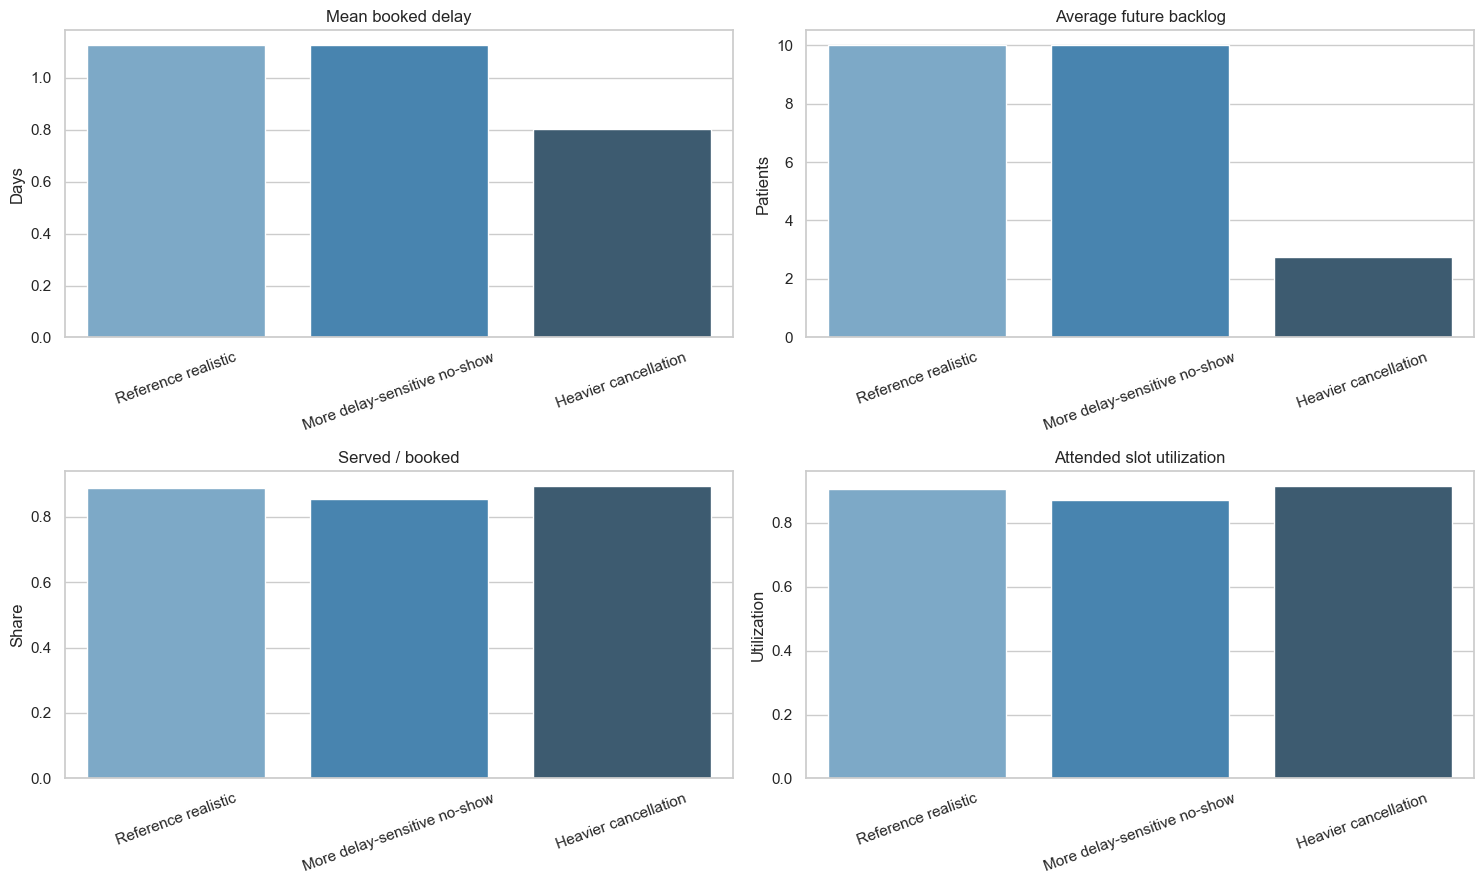

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

metric_specs = [
    ('mean_delay_booked', 'Mean booked delay', 'Days'),
    ('mean_future_backlog', 'Average future backlog', 'Patients'),
    ('served_per_booked', 'Served / booked', 'Share'),
    ('attended_slot_utilization', 'Attended slot utilization', 'Utilization'),
]

for axis, (metric, title, ylabel) in zip(axes.flat, metric_specs):
    sns.barplot(data=showcase_aggregate, x='scenario', y=metric, ax=axis, palette='Blues_d')
    axis.set_title(title)
    axis.set_xlabel('')
    axis.set_ylabel(ylabel)
    axis.tick_params(axis='x', rotation=20)

plt.tight_layout()


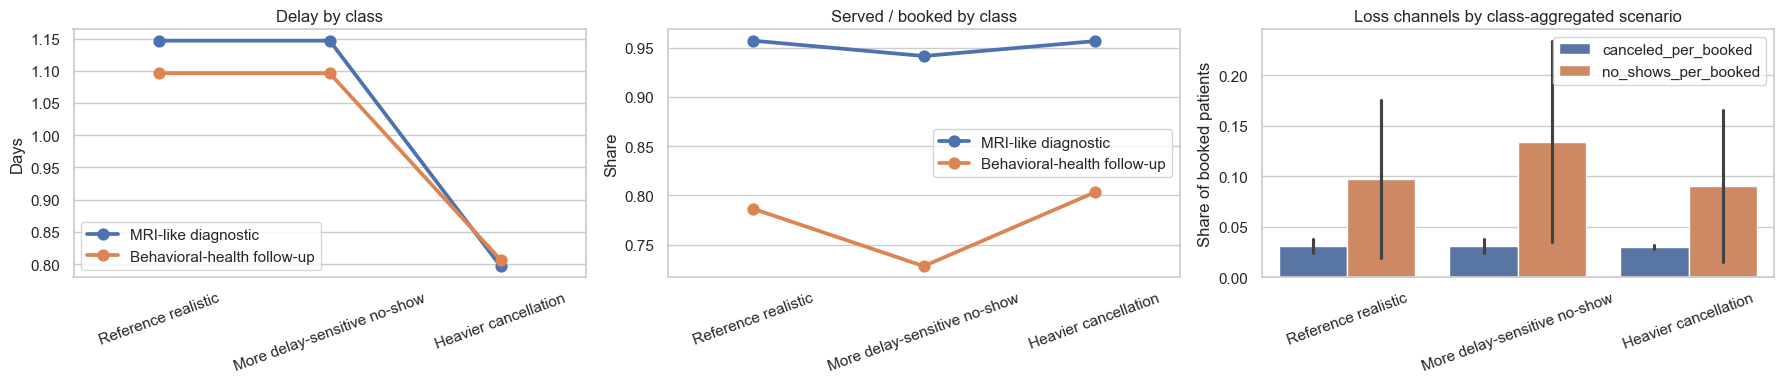

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)

sns.pointplot(data=showcase_by_class, x='scenario', y='mean_delay_booked', hue='label', ax=axes[0])
axes[0].set_title('Delay by class')
axes[0].set_xlabel('')
axes[0].set_ylabel('Days')
axes[0].tick_params(axis='x', rotation=20)

sns.pointplot(data=showcase_by_class, x='scenario', y='served_per_booked', hue='label', ax=axes[1])
axes[1].set_title('Served / booked by class')
axes[1].set_xlabel('')
axes[1].set_ylabel('Share')
axes[1].tick_params(axis='x', rotation=20)

class_loss_df = showcase_by_class.melt(
    id_vars=['scenario', 'label'],
    value_vars=['canceled_per_booked', 'no_shows_per_booked'],
    var_name='metric',
    value_name='value',
)
sns.barplot(data=class_loss_df, x='scenario', y='value', hue='metric', ax=axes[2])
axes[2].set_title('Loss channels by class-aggregated scenario')
axes[2].set_xlabel('')
axes[2].set_ylabel('Share of booked patients')
axes[2].tick_params(axis='x', rotation=20)

axes[0].legend(title='')
axes[1].legend(title='')
axes[2].legend(title='')

plt.tight_layout()


### How to Read the Showcase

The useful contrast is usually:

- stronger no-show sensitivity leaves the booking backlog almost unchanged, but hurts `served / booked` and attended utilization
- heavier cancellation can slightly relieve backlog and mean delay, but it does so by creating more pre-appointment losses
- the behavioral-health class should typically absorb more of the service loss because its no-show and cancellation functions are steeper


## 6. Sensitivity to Total Arrival Rate $\lambda$

This last block changes only the total arrival rate $\lambda$. The class mix $p$ and the behavior functions stay fixed, so the plots isolate pure congestion effects under FCFS.


In [13]:
# TOTAL_LAMBDA_GRID = [0.16, 0.22, 0.28, 0.34, 0.40, 0.46, 0.52, 0.58, 0.64, 0.70, 0.76, 0.82, 0.88, 0.94, 1.0, 1.06, 1.12, 1.18, 1.24, 1.30]
TOTAL_LAMBDA_GRID = [0.04, 0.08, 0.12, 0.16, 0.22, 0.28, 0.34, 0.40, 0.46, 0.52, 0.58, 0.64, 0.70, 0.76, 0.82, 0.88, 0.94, 1.0]


SWEEP_REPLICATIONS = 6

aggregate_sweep, class_sweep = run_fcfs_lambda_sweep(
    total_lambdas=TOTAL_LAMBDA_GRID,
    replications=SWEEP_REPLICATIONS,
)

display(aggregate_sweep.head())
display(class_sweep.head())


,replication,policy,arrivals,booked,balked,canceled,no_shows,served,mean_delay_booked,booked_within_access_target_per_arrival,booked_within_access_target_per_booked,served_per_booked,booked_slot_utilization,attended_slot_utilization,lambda_total
0,0,FCFSPolicy,343.0,341.0,2.0,0.0,12.0,329.0,0.041056,0.994169,1.0,0.964809,0.037370,0.036055,0.04
1,1,FCFSPolicy,366.0,355.0,11.0,0.0,18.0,337.0,0.033803,0.969945,1.0,0.949296,0.038904,0.036932,0.04
2,2,FCFSPolicy,336.0,322.0,14.0,1.0,19.0,302.0,0.027950,0.958333,1.0,0.937888,0.035178,0.033096,0.04
3,3,FCFSPolicy,392.0,383.0,9.0,0.0,19.0,364.0,0.041775,0.977041,1.0,0.950392,0.041973,0.039890,0.04
4,4,FCFSPolicy,370.0,360.0,10.0,1.0,19.0,340.0,0.047222,0.972973,1.0,0.944444,0.039342,0.037260,0.04


,class_id,label,mean_delay_booked,booked_within_access_target_per_arrival,served_per_booked,lambda_total,replication
0,1,MRI-like diagnostic,0.042857,1.000000,0.995238,0.04,0
1,2,Behavioral-health follow-up,0.038168,0.984962,0.916031,0.04,0
2,1,MRI-like diagnostic,0.043689,0.980952,0.995146,0.04,1
3,2,Behavioral-health follow-up,0.020134,0.955128,0.885906,0.04,1
4,1,MRI-like diagnostic,0.026596,0.974093,1.000000,0.04,2


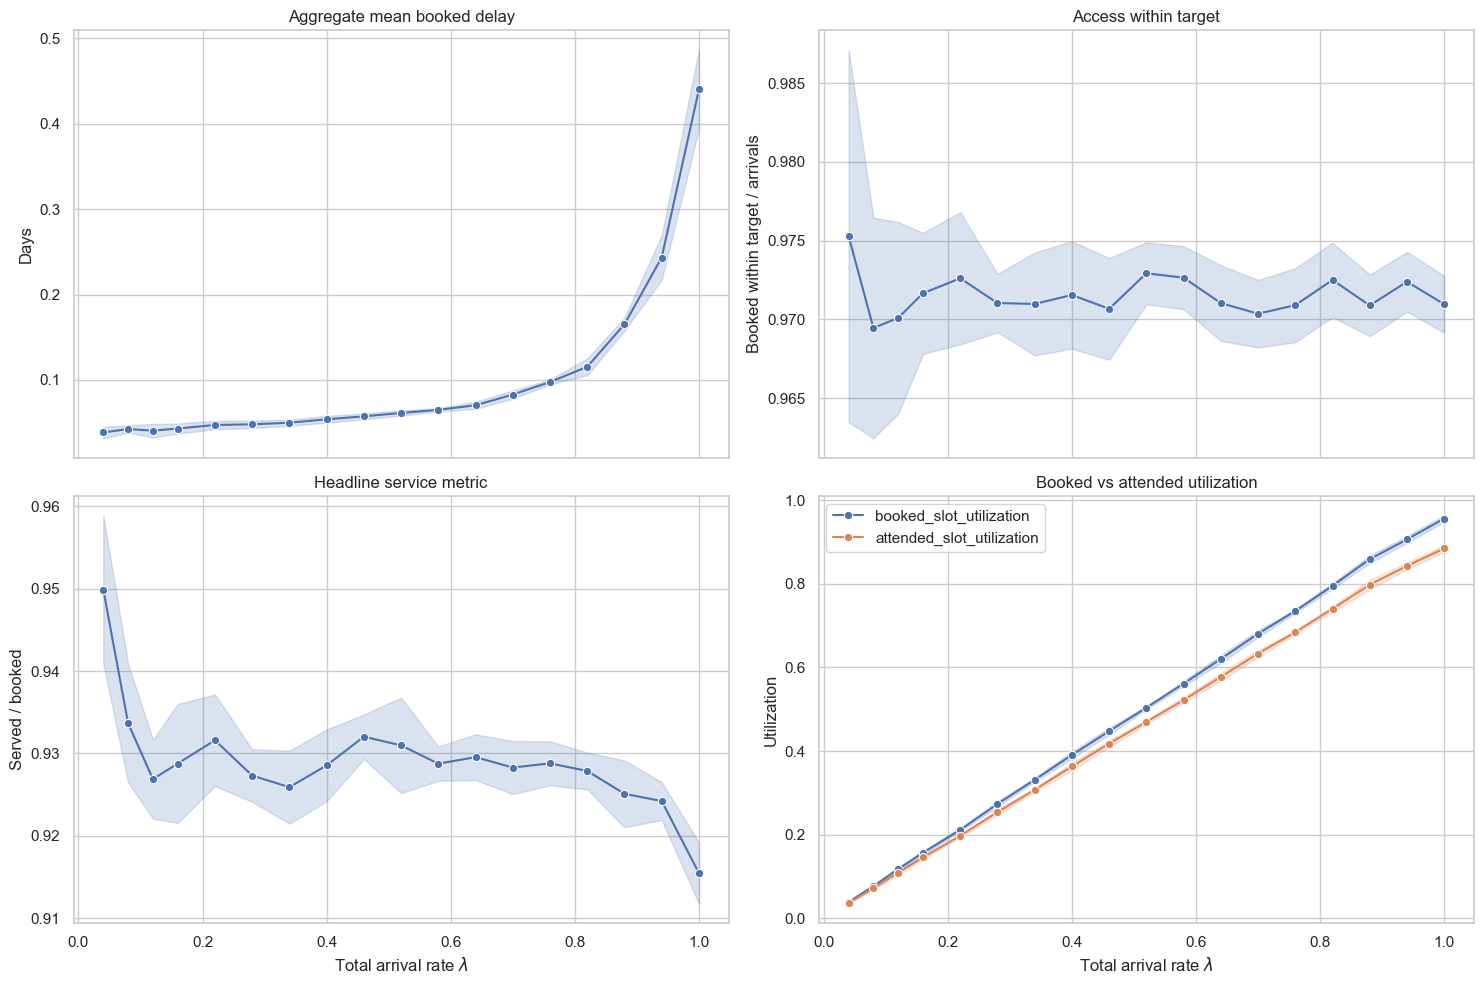

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)

sns.lineplot(
    data=aggregate_sweep,
    x="lambda_total",
    y="mean_delay_booked",
    estimator="mean",
    errorbar="sd",
    marker="o",
    ax=axes[0, 0],
)
axes[0, 0].set_title("Aggregate mean booked delay")
axes[0, 0].set_xlabel(r"Total arrival rate $\lambda$")
axes[0, 0].set_ylabel("Days")

sns.lineplot(
    data=aggregate_sweep,
    x="lambda_total",
    y="booked_within_access_target_per_arrival",
    estimator="mean",
    errorbar="sd",
    marker="o",
    ax=axes[0, 1],
)
axes[0, 1].set_title("Access within target")
axes[0, 1].set_xlabel(r"Total arrival rate $\lambda$")
axes[0, 1].set_ylabel("Booked within target / arrivals")

sns.lineplot(
    data=aggregate_sweep,
    x="lambda_total",
    y="served_per_booked",
    estimator="mean",
    errorbar="sd",
    marker="o",
    ax=axes[1, 0],
)
axes[1, 0].set_title("Headline service metric")
axes[1, 0].set_xlabel(r"Total arrival rate $\lambda$")
axes[1, 0].set_ylabel("Served / booked")

utilization_df = aggregate_sweep[["lambda_total", "booked_slot_utilization", "attended_slot_utilization"]].melt(
    id_vars="lambda_total",
    var_name="metric",
    value_name="value",
)
sns.lineplot(
    data=utilization_df,
    x="lambda_total",
    y="value",
    hue="metric",
    estimator="mean",
    errorbar="sd",
    marker="o",
    ax=axes[1, 1],
)
axes[1, 1].set_title("Booked vs attended utilization")
axes[1, 1].set_xlabel(r"Total arrival rate $\lambda$")
axes[1, 1].set_ylabel("Utilization")
axes[1, 1].legend(title="")

plt.tight_layout()


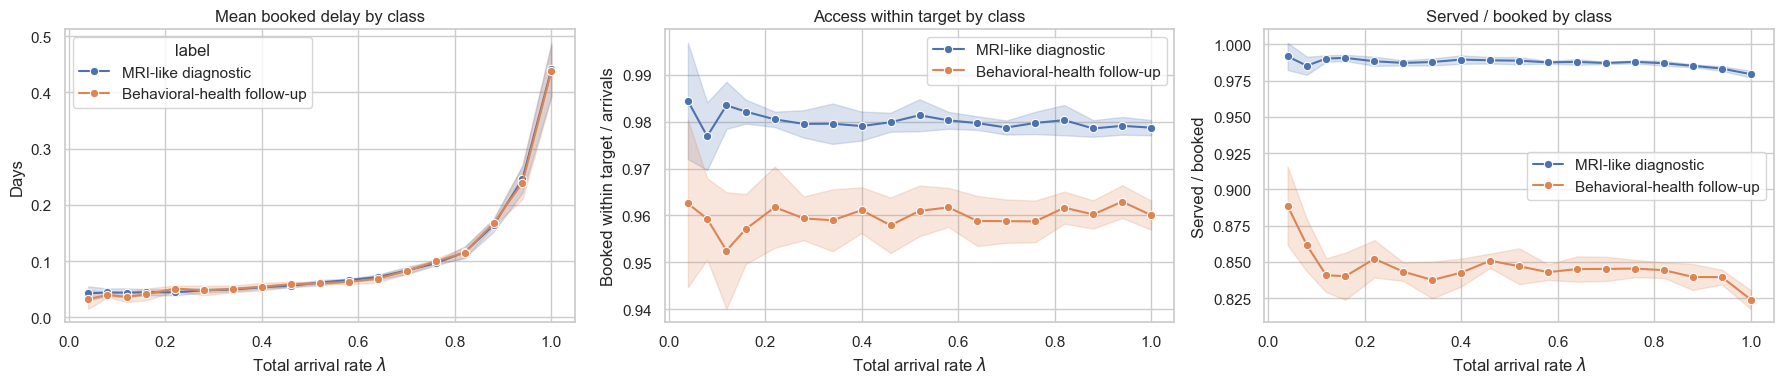

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)

sns.lineplot(
    data=class_sweep,
    x="lambda_total",
    y="mean_delay_booked",
    hue="label",
    estimator="mean",
    errorbar="sd",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Mean booked delay by class")
axes[0].set_xlabel(r"Total arrival rate $\lambda$")
axes[0].set_ylabel("Days")

sns.lineplot(
    data=class_sweep,
    x="lambda_total",
    y="booked_within_access_target_per_arrival",
    hue="label",
    estimator="mean",
    errorbar="sd",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Access within target by class")
axes[1].set_xlabel(r"Total arrival rate $\lambda$")
axes[1].set_ylabel("Booked within target / arrivals")
axes[1].legend(title="")

sns.lineplot(
    data=class_sweep,
    x="lambda_total",
    y="served_per_booked",
    hue="label",
    estimator="mean",
    errorbar="sd",
    marker="o",
    ax=axes[2],
)
axes[2].set_title("Served / booked by class")
axes[2].set_xlabel(r"Total arrival rate $\lambda$")
axes[2].set_ylabel("Served / booked")
axes[2].legend(title="")

plt.tight_layout()
